# Study Description

### Context & Background
This study investigates the musical characteristics of popular music by analyzing audio features from Spotify's most-streamed songs of 2023 (`spotify-2023.csv`). The dataset contains 953 tracks released or trending on Spotify throughout 2023, along with metadata and Spotify-engineered audio characteristics.

### Research Question
**What was the typical danceability score for the most streamed Spotify songs in 2023, and how are danceability scores distributed?**

### Target Variable
The primary quantitative variable of interest is **`danceability_%`**, which represents how suitable a track is for dancing on a scale from 0% to 100%. Spotify calculates this metric based on musical elements such as tempo, rhythm stability, beat strength, and overall regularity.


=== Summary Statistics for Danceability % ===
         Statistic          Value
             Count            953
              Mean         66.97%
Standard Deviation         14.63%
           Minimum          23.0%
          Q1 (25%)          57.0%
      Median (50%)          69.0%
          Q3 (75%)          78.0%
               IQR          21.0%
           Maximum          96.0%
  Mode (Frequency) 70% (43 songs)


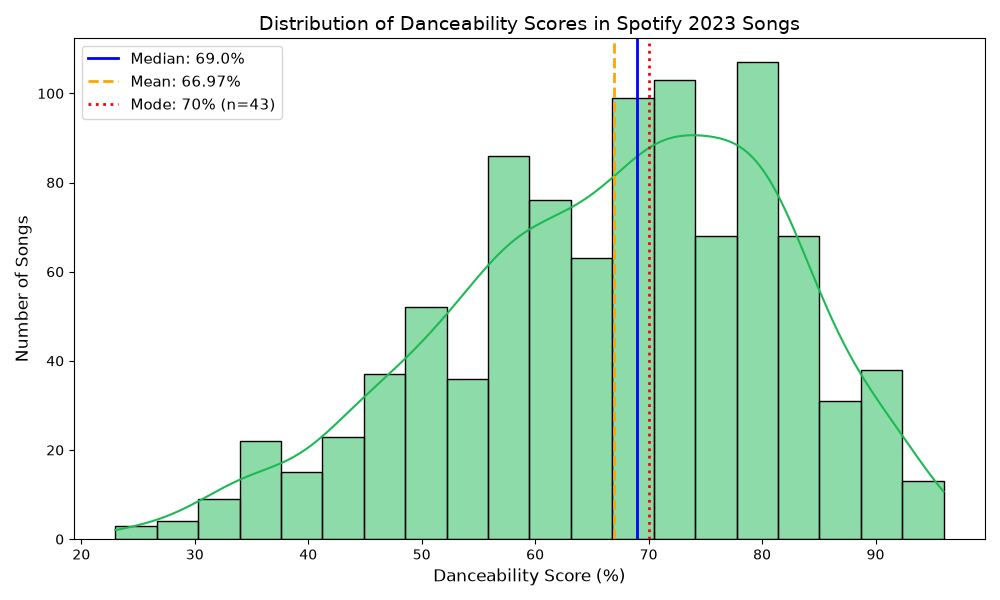

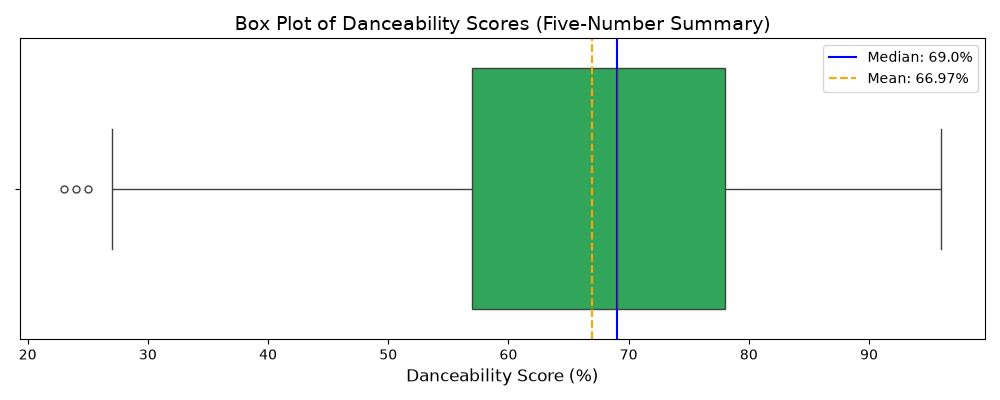

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Spotify 2023 dataset
df = pd.read_csv('spotify-2023.csv', encoding='cp1252')
danceability = df['danceability_%']

# Descriptive Statistics: Central Tendency & Five-Number Summary
mean_val = danceability.mean()
std_val = danceability.std()
median_val = danceability.median()
q1_val = danceability.quantile(0.25)
q3_val = danceability.quantile(0.75)
iqr_val = q3_val - q1_val
min_val = danceability.min()
max_val = danceability.max()
mode_val = danceability.mode()[0]
mode_count = danceability.value_counts().loc[mode_val]

summary_stats = pd.DataFrame({
    'Statistic': ['Count', 'Mean', 'Standard Deviation', 'Minimum', 'Q1 (25%)', 'Median (50%)', 'Q3 (75%)', 'IQR', 'Maximum', 'Mode (Frequency)'],
    'Value': [
        f"{len(danceability)}",
        f"{mean_val:.2f}%",
        f"{std_val:.2f}%",
        f"{min_val:.1f}%",
        f"{q1_val:.1f}%",
        f"{median_val:.1f}%",
        f"{q3_val:.1f}%",
        f"{iqr_val:.1f}%",
        f"{max_val:.1f}%",
        f"{mode_val}% ({mode_count} songs)"
    ]
})

print("=== Summary Statistics for Danceability % ===")
print(summary_stats.to_string(index=False))

# Visualization 1: Histogram with KDE and Measures of Center
plt.figure(figsize=(10, 6))
sns.histplot(danceability, bins=20, color='#1DB954', edgecolor='black', kde=True)
plt.axvline(median_val, color='blue', linestyle='-', linewidth=2, label=f'Median: {median_val:.1f}%')
plt.axvline(mean_val, color='orange', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}%')
plt.axvline(mode_val, color='red', linestyle=':', linewidth=2, label=f'Mode: {mode_val}% (n={mode_count})')
plt.title('Distribution of Danceability Scores in Spotify 2023 Songs', fontsize=14)
plt.xlabel('Danceability Score (%)', fontsize=12)
plt.ylabel('Number of Songs', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Visualization 2: Box Plot representing the Five-Number Summary & Skewness
plt.figure(figsize=(10, 4))
sns.boxplot(x=danceability, color='#1DB954', flierprops={'marker': 'o', 'markersize': 5})
plt.axvline(median_val, color='blue', linestyle='-', linewidth=1.5, label=f'Median: {median_val:.1f}%')
plt.axvline(mean_val, color='orange', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}%')
plt.title('Box Plot of Danceability Scores (Five-Number Summary)', fontsize=14)
plt.xlabel('Danceability Score (%)', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()


# Conclusion & Discussion

### Measures of Central Tendency: Median and Mean vs. Mode
When describing the central or typical value of a **quantitative variable** like `danceability_%`, the **median** and **mean** are standard and statistically appropriate metrics, whereas the **mode** is typically not used alone:
- **Median (69.0%):** The median represents the middle score of the distribution, where 50% of the tracks score higher and 50% score lower. Because `danceability_%` is moderately left-skewed with a longer lower tail extending down to 23.0%, the median is the most robust measure of central tendency because it is resistant to extreme low values.
- **Mean (66.97% ≈ 67.0%):** The mean measures the arithmetic average across all 953 tracks. It is slightly lower than the median (66.97% vs. 69.0%), which aligns with the negative skewness caused by the handful of lower-danceability tracks pulling the average downward.
- **Why Mode (70%) is Not Typically Used for Quantitative Data:** While the discrete mode is 70% (appearing 43 times), the mode is primarily intended for categorical or discrete nominal data. For continuous or quantitative measurements, the mode can be arbitrary or unstable because it depends heavily on rounding precision, bin definitions, or sample size fluctuations. While 70% happens to be the single most common whole-number percentage, stating that the "typical" score is 70% without the median or mean overlooks the quantitative nature and spread of the data.

### Five-Number Summary and Distribution Spread
- **Minimum:** 23.0%
- **First Quartile (Q1):** 57.0%
- **Median:** 69.0%
- **Third Quartile (Q3):** 78.0%
- **Maximum:** 96.0%
- **Interquartile Range (IQR):** 21.0% (Q3 − Q1), showing that the central 50% of popular songs have danceability scores clustered between 57% and 78%.
- **Standard Deviation:** 14.63%, reflecting moderate variability around the mean.

### Distribution Shape & Final Takeaway
The histogram and box plot demonstrate that danceability scores in Spotify's 2023 top tracks are **moderately left-skewed (negatively skewed)**. The distance from the minimum to the median (46.0%) is much greater than the distance from the median to the maximum (27.0%), and the mean (66.97%) lies below the median (69.0%).

In conclusion, a typical popular song in 2023 had a danceability score around **69% (median)** or **67% (mean)**. The fact that the median (69%), mean (~67%), and mode (70%) all converge closely demonstrates that popular tracks in 2023 were consistently characterized by high danceability.
